# Tutorial Part 4 --- Automated Hyperparameter Search

Parts 1-3 tuned the fairness weight $\mu$ by hand while fixing $\sigma$, $\lambda$, $\sigma_q$ at "reasonable" values.  But the fairness-accuracy trade-off depends on **all** hyperparameters jointly. A model with $\sigma = 0.5$, $\lambda = 10^{-3}$, $\mu = 3$ might *dominate* one with $\sigma = 1.0$, $\lambda = 10^{-2}$, $\mu = 10$ --- lower MSE **and** lower CKA simultaneously.  You cannot discover that by sweeping $\mu$ alone.

This tutorial replaces manual tuning with **Keras Tuner**, a black-box hyperparameter search library.  We define the full 6D search space, run 30 random trials, and extract the Pareto frontier over accuracy and fairness --- giving the richest picture of the trade-off available from a single experiment.

**What you will learn:**

1. Why exhaustive grid search is infeasible and random search is
   surprisingly effective.
2. How to configure `FairKernelRidgeHyperModel` with log-uniform
   sampling for scale parameters.
3. How to extract the Pareto frontier from multi-objective trial
   results and visualize the full fairness-accuracy landscape.

---
## The Curse of Manual Tuning

### Six hyperparameters, combinatorial explosion

Fair Kernel Ridge Regression has six tunable knobs:

| Symbol | Name | Role |
|--------|------|------|
| $\sigma$ | RBF bandwidth | controls kernel smoothness |
| $\lambda$ | ridge penalty | regularization strength |
| $\mu$ | fairness weight | accuracy-fairness balance |
| $\sigma_q$ | sensitive bandwidth | kernel width on the sensitive attribute |
| epochs | training iterations | gradient-descent budget |
| lr | learning rate | step size |

Suppose we test just 5 values per parameter on a grid.  The total number of configurations is

$$
5^6 = 15{,}625 \text{ trials.}
$$

At, say, 2 seconds per fit, that is **8.7 hours** of wall-clock time for a dataset with $n = 200$ points.  Worse, most of those configurations are wasted: if the optimum sits at $\sigma = 0.73$ and your grid levels are $\{0.1, 0.5, 1.0, 2.0, 5.0\}$, you never evaluate the interesting region.

### Why random search beats grid search

Bergstra & Bengio (2012) showed a striking result: **random search with $N$ trials explores $N$ unique values per dimension**, while grid search with the same budget explores only $N^{1/d}$ values per dimension (where $d$ is the number of parameters).  For $N = 30$ trials in $d = 6$ dimensions:

| Strategy | Unique values per dimension |
|----------|----------------------------|
| Grid search | $30^{1/6} \approx 1.8$ (not even 2 levels!) |
| Random search | 30 |

The intuition is simple: most hyperparameters have low effective dimensionality --- only 1 or 2 matter for any given metric.  Grid search wastes budget exploring irrelevant axes, while random search distributes samples across every axis independently.  For 30 trials, random search is the clear winner.

In [1]:
from __future__ import annotations

import os

os.environ["KERAS_BACKEND"] = "jax"

import keras_tuner as kt
import matplotlib.pyplot as plt
import numpy as np

from fairkl.tuning import FairKernelRidgeHyperModel
from _style import style_ax

---
## Synthetic Data

Same data as Parts 1-3: $y = \sin(x) + 3q + \varepsilon$, with $n = 200$ observations split 150/50 into train and validation sets.

In [2]:
rng = np.random.default_rng(0)
n = 200
x = rng.standard_normal((n, 1)).astype("float32")
q = rng.standard_normal((n, 1)).astype("float32")
X = np.hstack([x, q]).astype("float32")
y = (np.sin(x.ravel()) + 3.0 * q.ravel() + 0.3 * rng.standard_normal(n)).astype(
    "float32"
)

# Train / validation split
n_train = 150
X_train, X_val = X[:n_train], X[n_train:]
y_train, y_val = y[:n_train], y[n_train:]
q_train, q_val = q[:n_train], q[n_train:]
print(f"Train: {n_train},  Val: {n - n_train}")

Train: 150,  Val: 50


**Engineering trick: validation split.**  We hold out a separate validation set to get an unbiased estimate of generalization performance.  An alternative is K-fold cross-validation inside the tuner, but the cost would be $K \times 30 = 150$ fits (for $K = 5$) --- too expensive for this demo and unnecessary when the dataset is large enough for a clean held-out split.

---
## The Search Space

### FairKernelRidgeHyperModel

`fairkl.tuning.FairKernelRidgeHyperModel` is a `keras_tuner.HyperModel` subclass that packages the `FairKernelRidge` model together with its search space.  You hand it the train and validation arrays; it handles building, fitting, and scoring each trial internally.

In [3]:
hyper_model = FairKernelRidgeHyperModel(
    X_train=X_train,
    y_train=y_train,
    q_train=q_train,
    X_val=X_val,
    y_val=y_val,
    q_val=q_val,
)

### Engineering trick: log-sampling for scale parameters

The search space spans several orders of magnitude:

| Parameter | Range | Sampling |
|-----------|-------|----------|
| $\sigma$ (RBF bandwidth) | $[0.1,\; 5.0]$ | **log** |
| $\lambda$ (ridge) | $[10^{-4},\; 1.0]$ | **log** |
| $\mu$ (fairness) | $[0,\; 20]$ | linear (step=1) |
| $\sigma_q$ (sensitive bandwidth) | $[0.1,\; 5.0]$ | **log** |
| epochs | $[50,\; 300]$ | step=50 |
| lr (learning rate) | $[10^{-3},\; 0.05]$ | **log** |

**Engineering trick:** Four of six parameters ($\sigma$, $\lambda$, $\sigma_q$, lr) are positive scales that span orders of magnitude. Sampling them uniformly would pack most samples near the upper end of the range --- e.g., 90% of uniform samples from $[10^{-4}, 1]$ fall above $0.1$.  **Log-uniform sampling** instead draws uniformly in $\log$-space, ensuring equal probability per decade.  This is equivalent to sampling $u \sim \text{Uniform}(\log a, \log b)$ and returning $e^u$.  Only $\mu$ (an additive weight) and epochs (a discrete count) use linear or step sampling.

---
## Running the Search

### 30-trial random search

We configure `kt.RandomSearch` with 30 trials.  The primary objective is `val_mse` (minimized), but the `HyperModel` also records `val_cka` at each trial so we can build the Pareto plot afterward.

### Multi-objective: MSE + CKA

Keras Tuner optimizes a single scalar objective (here, `val_mse`). We record `val_cka` as a secondary metric but do **not** optimize it directly.  Instead, we extract the Pareto front post-hoc from the full set of $(MSE, CKA)$ pairs.  This keeps the search simple --- the tuner just minimizes MSE --- while still letting us discover the full trade-off surface.

In [4]:
tuner = kt.RandomSearch(
    hyper_model,
    objective=kt.Objective("val_mse", direction="min"),
    max_trials=30,
    overwrite=True,
    directory="/tmp/fairkl_tuning",
    project_name="fair_krr_tutorial",
)
tuner.search_space_summary()

Search space summary
Default search space size: 4
sigma (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 5.0, 'step': None, 'sampling': 'log'}
lam (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 1.0, 'step': None, 'sampling': 'log'}
mu (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 20.0, 'step': 1.0, 'sampling': 'linear'}
sigma_q (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 5.0, 'step': None, 'sampling': 'log'}


In [5]:
tuner.search()

Trial 30 Complete [00h 00m 11s]
val_mse: 4.191144943237305

Best val_mse So Far: 0.09077715873718262
Total elapsed time: 00h 05m 10s


**Engineering trick: warm-start inside each trial.**  Each call to `FairKernelRidge.fit()` internally warm-starts from the exact (closed-form) kernel ridge solution before running gradient descent on the fair objective.  This means that even with random hyperparameters, every trial starts near a reasonable solution and converges quickly --- the gradient-descent phase only needs to "push" the solution toward fairness, not learn the regression from scratch.

---
## Analyzing the Results

### Best hyperparameters

In [6]:
best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best hyperparameters (by val_mse):")
for k, v in best_hp.values.items():
    print(f"  {k}: {v}")

Best hyperparameters (by val_mse):
  sigma: 4.610089497870858
  lam: 0.0012567474533528458
  mu: 4.0
  sigma_q: 2.8264078217348167
  epochs: 150
  lr: 0.004773861503212613


### All trials: the MSE-CKA landscape

We extract `val_mse`, `val_cka`, and $\mu$ from every completed trial.  This gives us a 30-point sample of the 6D hyperparameter space projected onto the two axes we care about.

In [7]:
all_trials = tuner.oracle.get_best_trials(num_trials=30)
trial_mses, trial_ckas, trial_mus = [], [], []

for trial in all_trials:
    hp = trial.hyperparameters.values
    mse_obs = trial.metrics.metrics["val_mse"].get_history()
    cka_obs = trial.metrics.metrics["val_cka"].get_history()
    trial_mses.append(mse_obs[-1].value[0])
    trial_ckas.append(cka_obs[-1].value[0])
    trial_mus.append(hp["mu"])

trial_mses = np.array(trial_mses)
trial_ckas = np.array(trial_ckas)
trial_mus = np.array(trial_mus)

print(f"Collected {len(trial_mses)} trials")
print(f"MSE  range: [{trial_mses.min():.4f}, {trial_mses.max():.4f}]")
print(f"CKA  range: [{trial_ckas.min():.4f}, {trial_ckas.max():.4f}]")
print(f"mu   range: [{trial_mus.min():.0f}, {trial_mus.max():.0f}]")

Collected 30 trials
MSE  range: [0.0908, 7.4430]
CKA  range: [0.0151, 0.6491]
mu   range: [1, 20]


### Extracting the Pareto frontier

Given a set of trials with two objectives $(MSE_i, CKA_i)$, we want the **Pareto-optimal** subset: trials that cannot be improved on one objective without worsening the other.

Formally, trial $i$ **dominates** trial $j$ if and only if

$$
MSE_i \leq MSE_j \quad \text{and} \quad CKA_i \leq CKA_j
$$

with **at least one strict inequality**.  A trial is **Pareto-optimal** if and only if no other trial dominates it.  The set of all Pareto-optimal trials forms the **Pareto frontier** --- the lower-left boundary of the achievable region in $(CKA, MSE)$ space.

### Engineering trick: Pareto dominance filtering

**Engineering trick:** The brute-force algorithm below checks every pair of trials --- $O(n^2)$ comparisons.  For 30 trials ($30^2 = 900$ comparisons) this is instantaneous.  For larger searches ($n > 1000$), you would want a sorting-based algorithm: sort trials by one objective, then sweep through in order, tracking the running minimum of the other objective.  This reduces the cost to $O(n \log n)$.  Alternatively, `scipy.spatial.ConvexHull` on the $(CKA, MSE)$ points gives the lower-left envelope in $O(n \log n)$.

In [8]:
is_pareto = np.ones(len(trial_mses), dtype=bool)
for i in range(len(trial_mses)):
    for j in range(len(trial_mses)):
        if (
            i != j
            and trial_mses[j] <= trial_mses[i]
            and trial_ckas[j] <= trial_ckas[i]
            and (trial_mses[j] < trial_mses[i] or trial_ckas[j] < trial_ckas[i])
        ):
            is_pareto[i] = False
            break

n_pareto = is_pareto.sum()
print(f"{n_pareto} Pareto-optimal trials out of {len(trial_mses)}")

# Sort Pareto front by CKA for the connected line plot
pareto_idx = np.where(is_pareto)[0]
sort_order = np.argsort(trial_ckas[pareto_idx])
pareto_ckas = trial_ckas[pareto_idx][sort_order]
pareto_mses = trial_mses[pareto_idx][sort_order]
pareto_mus = trial_mus[pareto_idx][sort_order]

12 Pareto-optimal trials out of 30


---
## Results: The Full Fairness-Accuracy Landscape

The plot below shows every trial as a point in $(CKA, MSE)$ space, colored by the fairness weight $\mu$.  The Pareto frontier connects the non-dominated trials --- the best achievable trade-offs from this search.

Points in the **lower-left** corner are ideal: low error and low dependence on the sensitive attribute.  The Pareto frontier traces the boundary of what is achievable --- any improvement in fairness (lower CKA) must come at the cost of accuracy (higher MSE), and vice versa.  Points far from the frontier are suboptimal: another hyperparameter configuration achieves both better accuracy and better fairness.

Notice that the frontier is not parameterized by $\mu$ alone. Different $\sigma$, $\lambda$, and $\sigma_q$ values shift the entire trade-off curve.  This is precisely why joint hyperparameter search --- rather than sweeping $\mu$ in isolation --- gives a tighter frontier.

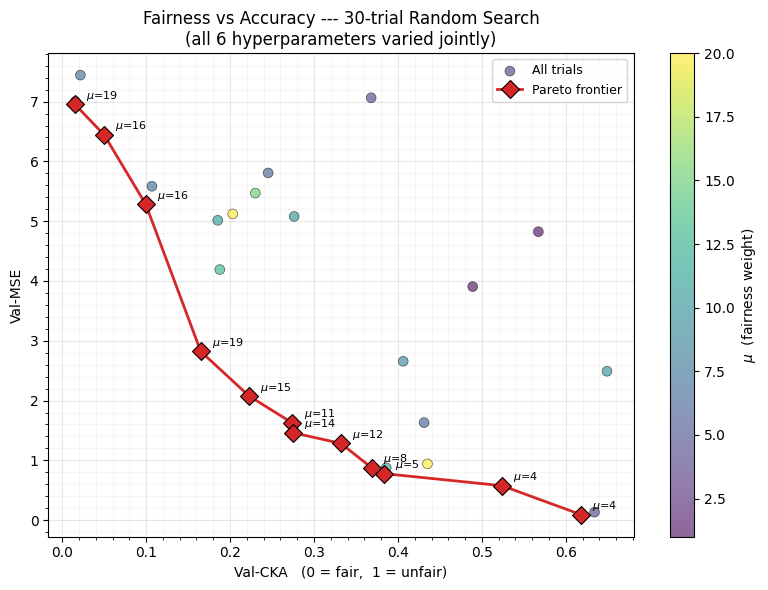

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

# All trials, colored by mu
sc = ax.scatter(
    trial_ckas,
    trial_mses,
    c=trial_mus,
    cmap="viridis",
    s=50,
    edgecolors="k",
    linewidths=0.5,
    alpha=0.6,
    zorder=3,
    label="All trials",
)
plt.colorbar(sc, ax=ax, label="$\\mu$  (fairness weight)")

# Pareto frontier overlay
ax.plot(
    pareto_ckas,
    pareto_mses,
    "D-",
    color="C3",
    lw=2,
    markersize=9,
    markeredgecolor="k",
    markeredgewidth=0.8,
    zorder=5,
    label="Pareto frontier",
)

# Annotate Pareto points with mu
for i in range(len(pareto_ckas)):
    ax.annotate(
        f"$\\mu$={pareto_mus[i]:.0f}",
        (pareto_ckas[i], pareto_mses[i]),
        textcoords="offset points",
        xytext=(8, 4),
        fontsize=8,
    )

ax.set_xlabel("Val-CKA   (0 = fair,  1 = unfair)")
ax.set_ylabel("Val-MSE")
ax.set_title(
    "Fairness vs Accuracy --- 30-trial Random Search\n"
    "(all 6 hyperparameters varied jointly)",
    fontsize=12,
)
ax.legend(fontsize=9)
style_ax(ax)
plt.tight_layout()
plt.show()

**Interpreting the landscape.**  Several patterns typically emerge:

- **Low $\mu$ trials** (dark points) cluster in the upper-left: good
  accuracy but high CKA, because the model freely exploits the   sensitive attribute.
- **High $\mu$ trials** (bright points) spread toward the lower-right:
  fairness improves at the cost of MSE.
- **The frontier itself** shows that the cost of fairness is not
  linear.  The first units of fairness are cheap (CKA drops sharply   with little MSE increase); later units are expensive.
- **Off-frontier points** reveal that some hyperparameter
  combinations are simply bad --- poor $\sigma$ or $\lambda$ choices   waste capacity regardless of $\mu$.

The key insight is that $\sigma$ and $\lambda$ determine the *capacity* of the model, while $\mu$ controls how that capacity is allocated between fitting the target and ignoring the sensitive attribute.  Searching all six parameters jointly finds combinations where the capacity is well-matched to the data, so the fairness penalty has the least impact on accuracy.

---

## Series Summary

| Part | Focus | Method | Pareto source |
|------|-------|--------|---------------|
| [Part 1](tutorial_fair_krr_part1.py) | Math & primitives | Manual KRR from `keras.ops` | Training metrics, $\mu$ sweep |
| [Part 2](tutorial_fair_krr_part2.py) | Scikit-learn & CV | `FairKernelRidgeCV` wrapper | Cross-validated metrics |
| [Part 3](tutorial_fair_krr_part3.py) | fairkl API & Keras | `FairKernelRidge` model | Training metrics, $\mu$ sweep |
| **Part 4** | **Automated search** | **Keras Tuner (30 random trials)** | **Multi-HP Pareto from all trials** |

The progression mirrors real-world practice: understand the math (Part 1), prototype with familiar tools (Part 2), adopt the production API (Part 3), and automate the search (Part 4).  Each step trades manual control for automation, ultimately letting the search algorithm explore the 6D space more efficiently than any human could by hand.